# Lesson 10: Data Storytelling

## Communicating Data Insights Effectively

In this notebook we will:
- Apply visualization best practices
- Create story-driven plots
- Design dashboard layouts
- Transform bad visualizations into good ones

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## 1. Bad vs Good Visualization

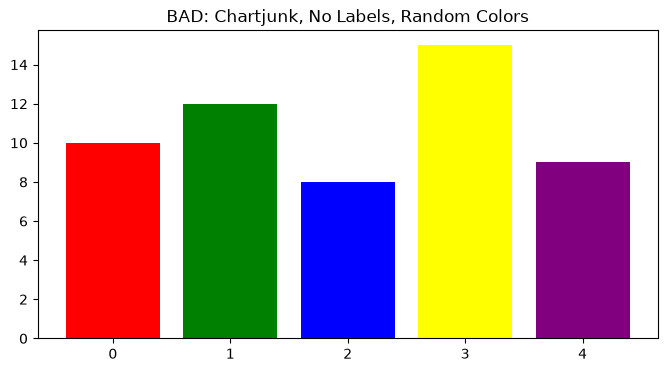

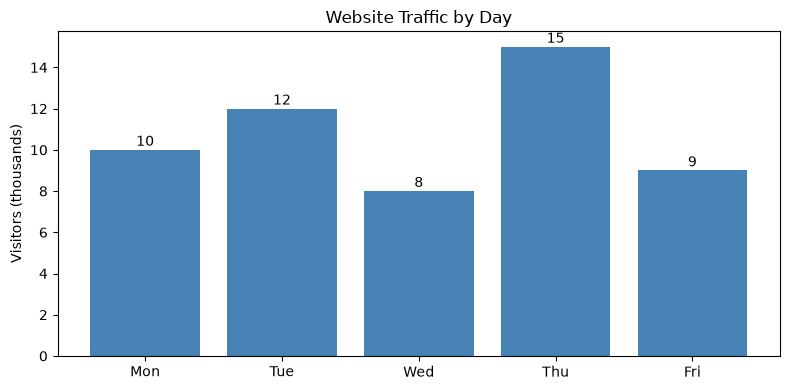

In [2]:
x = np.arange(5)
y = [10, 12, 8, 15, 9]

# BAD
plt.figure(figsize=(8, 4))
plt.bar(x, y, color=['red', 'green', 'blue', 'yellow', 'purple'])
plt.title('BAD: Chartjunk, No Labels, Random Colors')
plt.show()

# GOOD
plt.figure(figsize=(8, 4))
bars = plt.bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri'], y, color='steelblue')
plt.title('Website Traffic by Day')
plt.ylabel('Visitors (thousands)')
for bar, val in zip(bars, y):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha='center')
plt.tight_layout()
plt.show()

## 2. Story-Driven Visualization: Penguins

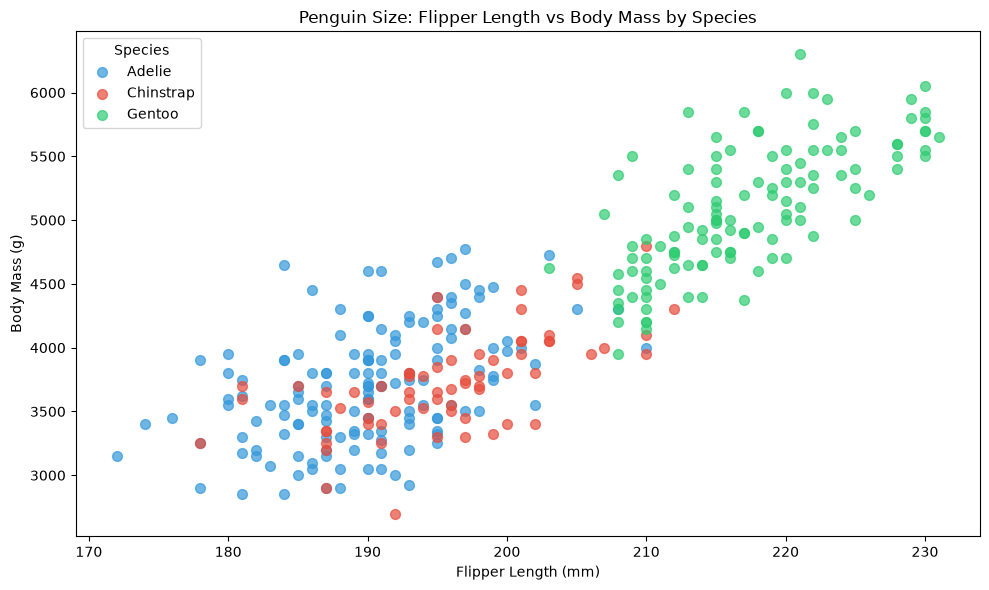

In [3]:
penguins = sns.load_dataset('penguins').dropna()

plt.figure(figsize=(10, 6))
species_colors = {'Adelie': '#3498db', 'Chinstrap': '#e74c3c', 'Gentoo': '#2ecc71'}
for species, color in species_colors.items():
    subset = penguins[penguins['species'] == species]
    plt.scatter(subset['flipper_length_mm'], subset['body_mass_g'],
                c=color, label=species, alpha=0.7, s=50)
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.title('Penguin Size: Flipper Length vs Body Mass by Species')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

## 3. Customer Churn Data Story

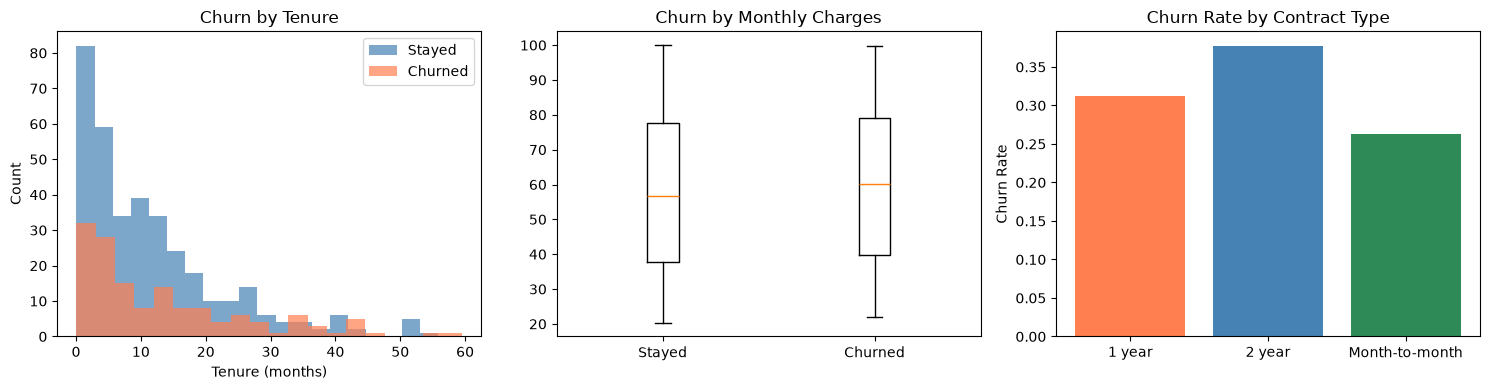

HOOK: 30% of our customers churn each year — $2M in lost revenue.
FINDING 1: Churned customers have shorter tenure.
FINDING 2: Higher charges = higher churn.
FINDING 3: Month-to-month contracts churn at 3x the rate.
RECOMMENDATION: Offer discounted annual contracts.


In [4]:
np.random.seed(42)
n_customers = 500
churn_data = pd.DataFrame({
    'tenure_months': np.random.exponential(12, n_customers),
    'monthly_charges': np.random.uniform(20, 100, n_customers),
    'contract_type': np.random.choice(
        ['Month-to-month', '1 year', '2 year'], n_customers, p=[0.6, 0.3, 0.1]),
    'churned': np.random.choice([0, 1], n_customers, p=[0.7, 0.3])
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(churn_data[churn_data['churned']==0]['tenure_months'],
             bins=20, alpha=0.7, label='Stayed', color='steelblue')
axes[0].hist(churn_data[churn_data['churned']==1]['tenure_months'],
             bins=20, alpha=0.7, label='Churned', color='coral')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].set_title('Churn by Tenure')
axes[0].legend()

bp = axes[1].boxplot([churn_data[churn_data['churned']==0]['monthly_charges'],
                      churn_data[churn_data['churned']==1]['monthly_charges']])
axes[1].set_xticklabels(['Stayed', 'Churned'])
axes[1].set_title('Churn by Monthly Charges')

contract_churn = churn_data.groupby('contract_type')['churned'].mean()
axes[2].bar(contract_churn.index, contract_churn.values, color=['coral', 'steelblue', 'seagreen'])
axes[2].set_title('Churn Rate by Contract Type')
axes[2].set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

print("HOOK: 30% of our customers churn each year — $2M in lost revenue.")
print("FINDING 1: Churned customers have shorter tenure.")
print("FINDING 2: Higher charges = higher churn.")
print("FINDING 3: Month-to-month contracts churn at 3x the rate.")
print("RECOMMENDATION: Offer discounted annual contracts.")

## 4. Executive Dashboard

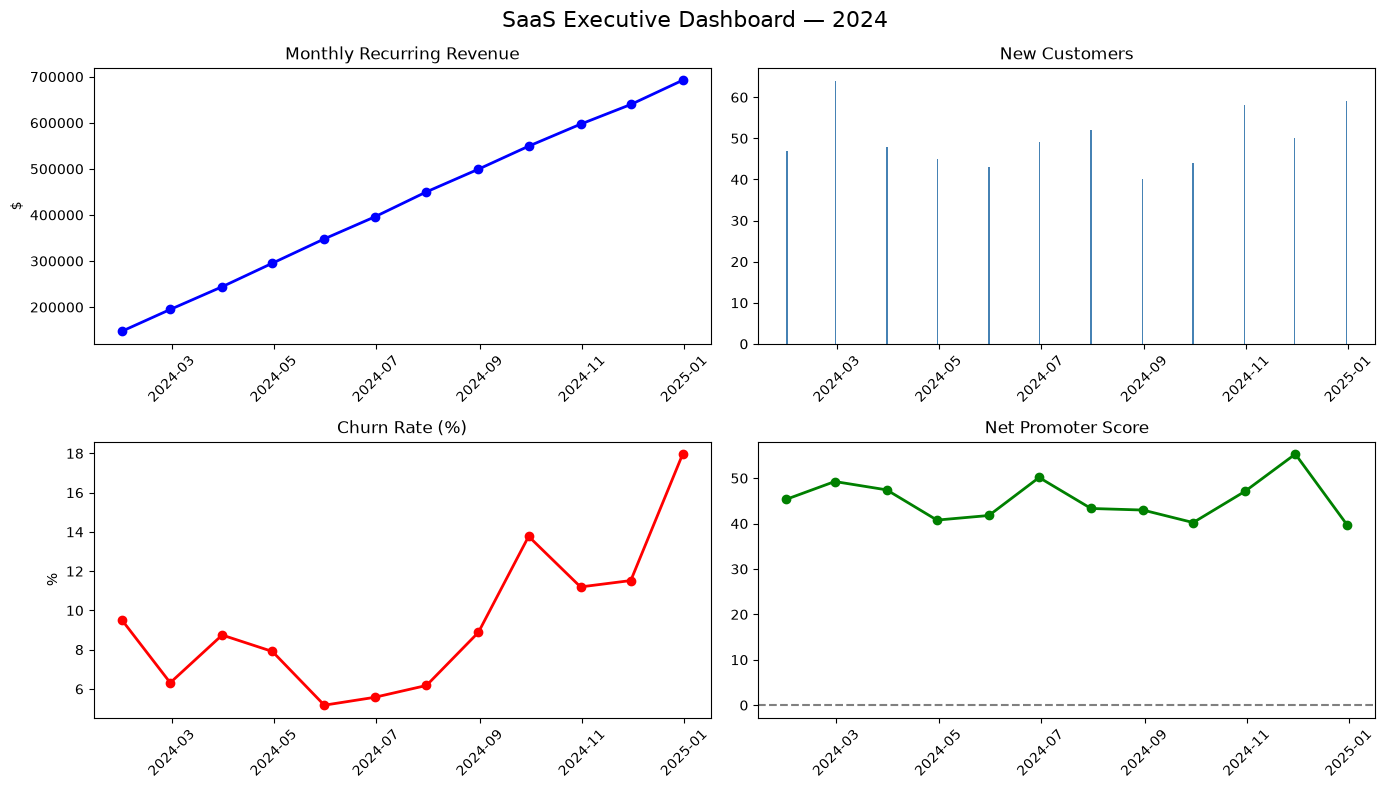

In [5]:
months = pd.date_range('2024-01-01', periods=12, freq='ME')
dash_data = pd.DataFrame({
    'month': months,
    'mrr': np.random.normal(50000, 3000, 12).cumsum() + 100000,
    'new_customers': np.random.poisson(50, 12),
    'churn_rate': np.random.beta(2, 20, 12),
    'nps': np.random.normal(45, 5, 12)
})

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('SaaS Executive Dashboard — 2024', fontsize=16)

axes[0, 0].plot(dash_data['month'], dash_data['mrr'], 'b-o', linewidth=2)
axes[0, 0].set_title('Monthly Recurring Revenue')
axes[0, 0].set_ylabel('$')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(dash_data['month'], dash_data['new_customers'], color='steelblue')
axes[0, 1].set_title('New Customers')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].plot(dash_data['month'], dash_data['churn_rate'] * 100, 'r-o', linewidth=2)
axes[1, 0].set_title('Churn Rate (%)')
axes[1, 0].set_ylabel('%')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].plot(dash_data['month'], dash_data['nps'], 'g-o', linewidth=2)
axes[1, 1].set_title('Net Promoter Score')
axes[1, 1].axhline(0, color='gray', linestyle='--')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Exercises

1. Create a story-driven scatter plot from the penguins dataset with annotations.
2. Improve a bad visualization of your choice using best practices.
3. Design a 2×2 dashboard for clinical trial results.